
Dataset 1: Разные средние (10,12,14), равные дисперсии (2)

1. Критерий Фишера:
   F-статистика = 40.9756
   p-value = 0.000000
   Вывод: Отвергаем H0 - фактор влияет

2. Критерий Краскела-Уоллиса:
   H-статистика = 43.2739
   p-value = 0.000000
   Вывод: Отвергаем H0 - фактор влияет

3. Критерий Джонкхиера:
   J-статистика = 414.00
   p-value = 0.000000
   Вывод: Отвергаем H0 - есть монотонность

Dataset 2: Разные средние (10,11,12), разные дисперсии (1,3,5)

1. Критерий Фишера:
   F-статистика = 8.8859
   p-value = 0.000308
   Вывод: Отвергаем H0 - фактор влияет

2. Критерий Краскела-Уоллиса:
   H-статистика = 10.2735
   p-value = 0.005877
   Вывод: Отвергаем H0 - фактор влияет

3. Критерий Джонкхиера:
   J-статистика = 933.00
   p-value = 0.002009
   Вывод: Отвергаем H0 - есть монотонность

Dataset 3: Одинаковые средние (0,0,0), равные дисперсии (1)

1. Критерий Фишера:
   F-статистика = 0.3430
   p-value = 0.710574
   Вывод: Принимаем H0 - фактор не влияет

2. Критерий Краскела-Уо

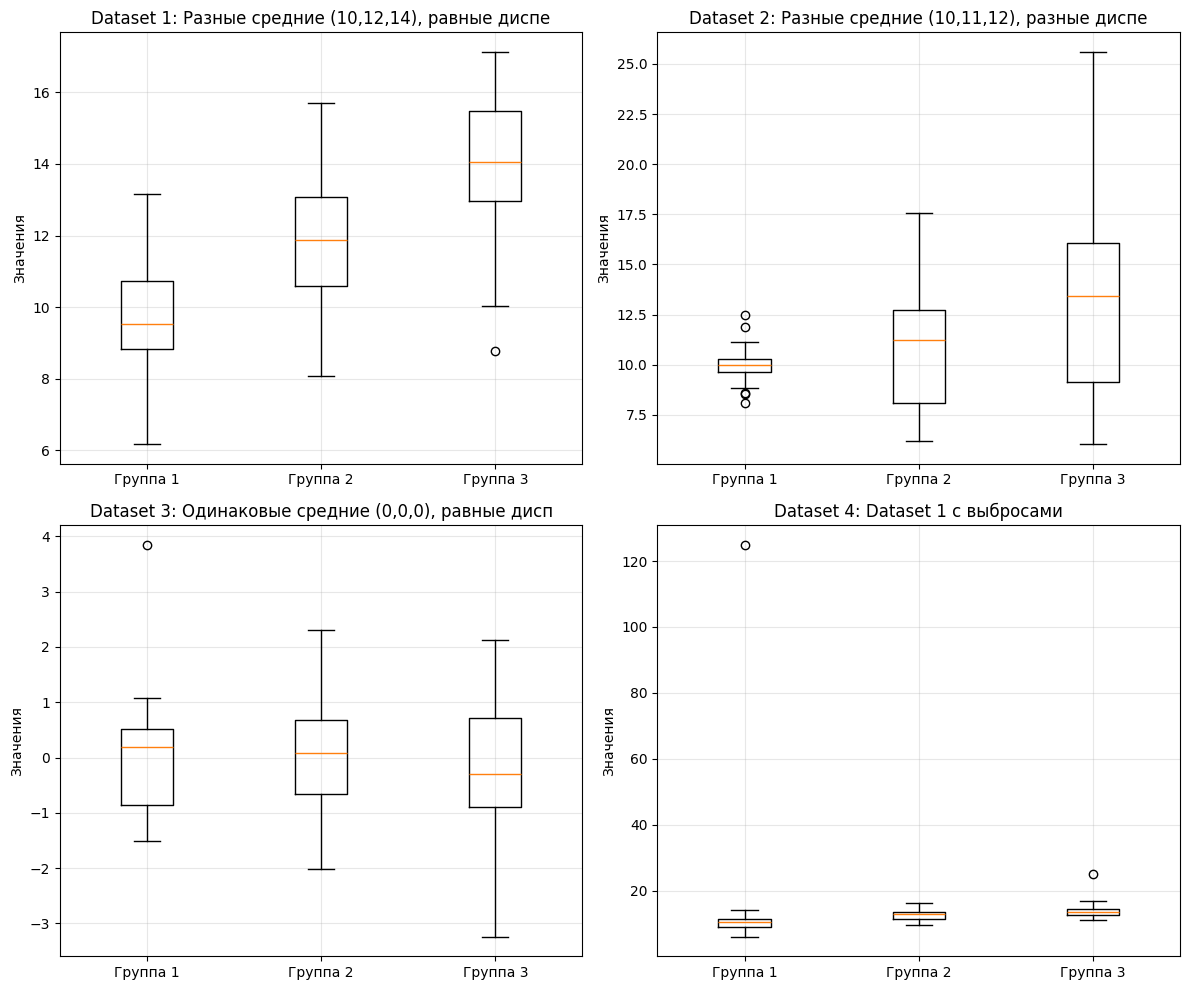

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Функции критериев
def fisher_test(groups):
    f_stat, p_value = stats.f_oneway(*groups)
    return f_stat, p_value

def kruskal_wallis_test(groups):
    h_stat, p_value = stats.kruskal(*groups)
    return h_stat, p_value

def jonckheere_test(groups, alternative='increasing'):
    k = len(groups)
    J_stat = 0
    for i in range(k):
        for j in range(i+1, k):
            u_stat, _ = stats.mannwhitneyu(groups[i], groups[j], alternative='less')
            J_stat += u_stat
    n = np.array([len(g) for g in groups])
    N = sum(n)
    E_J = (N**2 - np.sum(n**2)) / 4
    all_values = np.concatenate(groups)
    sorted_indices = np.argsort(all_values)
    sorted_values = all_values[sorted_indices]
    ties = []
    i = 0
    while i < len(sorted_values):
        j = i
        while j < len(sorted_values) and sorted_values[j] == sorted_values[i]:
            j += 1
        if j - i > 1:
            ties.append(j - i)
        i = j
    sum_ties_cube = sum(t**3 - t for t in ties)
    Var_J = (N**2 * (2*N + 3) - np.sum(n**2 * (2*n + 3)) - sum_ties_cube) / 72
    z = (J_stat - E_J) / np.sqrt(Var_J)
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return J_stat, p_value

# Генерация датасетов
group1_1 = np.random.normal(10, 2, 30)
group2_1 = np.random.normal(12, 2, 30)
group3_1 = np.random.normal(14, 2, 30)

group1_2 = np.random.normal(10, 1, 30)
group2_2 = np.random.normal(11, 3, 30)
group3_2 = np.random.normal(12, 5, 30)

group1_3 = np.random.normal(0, 1, 30)
group2_3 = np.random.normal(0, 1, 30)
group3_3 = np.random.normal(0, 1, 30)

group1_4 = np.random.normal(10, 2, 30)
group2_4 = np.random.normal(12, 2, 30)
group3_4 = np.random.normal(14, 2, 30)
group1_4 = np.append(group1_4, 125)
group3_4 = np.append(group3_4, 25)

datasets = {
    "Dataset 1: Разные средние (10,12,14), равные дисперсии (2)": [group1_1, group2_1, group3_1],
    "Dataset 2: Разные средние (10,11,12), разные дисперсии (1,3,5)": [group1_2, group2_2, group3_2],
    "Dataset 3: Одинаковые средние (0,0,0), равные дисперсии (1)": [group1_3, group2_3, group3_3],
    "Dataset 4: Dataset 1 с выбросами": [group1_4, group2_4, group3_4]
}

# Анализ
results_list = []
for dataset_name, groups in datasets.items():
    print(f"\n{'='*80}")
    print(f"{dataset_name}")
    print(f"{'='*80}")

    f_stat, p_fisher = fisher_test(groups)
    h_stat, p_kw = kruskal_wallis_test(groups)
    j_stat, p_jt = jonckheere_test(groups)

    print(f"\n1. Критерий Фишера:")
    print(f"   F-статистика = {f_stat:.4f}")
    print(f"   p-value = {p_fisher:.6f}")
    print(f"   Вывод: {'Отвергаем H0 - фактор влияет' if p_fisher < 0.05 else 'Принимаем H0 - фактор не влияет'}")

    print(f"\n2. Критерий Краскела-Уоллиса:")
    print(f"   H-статистика = {h_stat:.4f}")
    print(f"   p-value = {p_kw:.6f}")
    print(f"   Вывод: {'Отвергаем H0 - фактор влияет' if p_kw < 0.05 else 'Принимаем H0 - фактор не влияет'}")

    print(f"\n3. Критерий Джонкхиера:")
    print(f"   J-статистика = {j_stat:.2f}")
    print(f"   p-value = {p_jt:.6f}")
    print(f"   Вывод: {'Отвергаем H0 - есть монотонность' if p_jt < 0.05 else 'Принимаем H0 - фактор не влияет'}")

    results_list.append({
        'Dataset': dataset_name,
        'Fisher_p': p_fisher,
        'KW_p': p_kw,
        'Jonckheere_p': p_jt
    })

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, (dataset_name, groups) in enumerate(datasets.items()):
    ax = axes[idx // 2, idx % 2]
    ax.boxplot(groups, labels=['Группа 1', 'Группа 2', 'Группа 3'])
    ax.set_title(dataset_name[:50])
    ax.set_ylabel('Значения')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()